# Задание
Эксперимент проходил с 2025-11-21 по 2025-11-27 включительно.

Проанализируйте тест между группами 0 и 3 и между группами 1 и 2 по метрике линеаризованных лайков. В группах 3 и 2 был использованы новые алгоритмы, группы 0 и 1 - контрольные.

Необходимо ответить на вопросы: Видно ли отличие? Стало ли 𝑝−𝑣𝑎𝑙𝑢𝑒 меньше?

In [1]:
import pandas as pd
import pandahouse as ph
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

In [2]:
connection = {'host': 'http://clickhouse.lab.karpov.courses:8123',
'database':'simulator_20251220',
'user':'student',
'password':'dpo_python_2020'
}

# Проанализируем тест между группами 0 и 3 по метрике линеаризованных лайков.

In [3]:
q = """
SELECT exp_group, 
  user_id,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as CTR
FROM simulator_20251220.feed_actions 
WHERE toDate(time) between '2025-11-21' and '2025-11-27'
    and exp_group in (0,3)
GROUP BY exp_group,user_id
"""

In [4]:
df = ph.read_clickhouse(q, connection=connection)

In [5]:
df

,exp_group,user_id,likes,views,CTR
0,3,115383,12,44,0.272727
1,3,123580,2,11,0.181818
2,0,4944,8,41,0.195122
3,0,4504,5,15,0.333333
4,0,121508,6,25,0.240000
...,...,...,...,...,...
19917,3,13781,10,27,0.370370
19918,3,130651,18,98,0.183673
19919,0,3681,7,55,0.127273
19920,3,122008,5,41,0.121951


In [6]:
# Считаем общий CTR в контрольной группе  𝐶𝑇𝑅𝑐𝑜𝑛𝑡𝑟𝑜𝑙=𝑠𝑢𝑚(𝑙𝑖𝑘𝑒𝑠)/𝑠𝑢𝑚(𝑣𝑖𝑒𝑤𝑠)
CTRcontrol=df[df.exp_group==0].likes.sum()/df[df.exp_group==0].views.sum()
CTRcontrol

0.20983799195924746

In [7]:
# Посчитаем в обеих группах поюзерную метрику  𝑙𝑖𝑛𝑒𝑎𝑟𝑖𝑧𝑒𝑑_𝑙𝑖𝑘𝑒𝑠=𝑙𝑖𝑘𝑒𝑠−𝐶𝑇𝑅𝑐𝑜𝑛𝑡𝑟𝑜𝑙∗𝑣𝑖𝑒𝑤𝑠
df['lin_likes'] = df['likes'] - CTRcontrol * df['views']
df

,exp_group,user_id,likes,views,CTR,lin_likes
0,3,115383,12,44,0.272727,2.767128
1,3,123580,2,11,0.181818,-0.308218
2,0,4944,8,41,0.195122,-0.603358
3,0,4504,5,15,0.333333,1.852430
4,0,121508,6,25,0.240000,0.754050
...,...,...,...,...,...,...
19917,3,13781,10,27,0.370370,4.334374
19918,3,130651,18,98,0.183673,-2.564123
19919,0,3681,7,55,0.127273,-4.541090
19920,3,122008,5,41,0.121951,-3.603358


In [8]:
#сравниваем  t-тестом отличия в группах по метрике 𝑙𝑖𝑛𝑒𝑎𝑟𝑖𝑧𝑒𝑑_𝑙𝑖𝑘𝑒𝑠
stats.ttest_ind(df[df.exp_group == 0].lin_likes,
                df[df.exp_group == 3].lin_likes,
                equal_var=False)


Ttest_indResult(statistic=-16.186230032932844, pvalue=1.4918137745326139e-58)

In [9]:
#сравниваем  t-тестом отличия в группах по метрике CTR
stats.ttest_ind(df[df.exp_group == 0].CTR,
                df[df.exp_group == 3].CTR,
                equal_var=False)

Ttest_indResult(statistic=-13.935320516755773, pvalue=6.216047483062228e-44)

Согласно результатам t-теста по метрике линеаризованных лайков и по ctr в группах 0 и 3 p-value очень мал (примерно равен 0, меньше 0.05), это означает, что исследуемая метрика групп отличается в двух группах. 

𝑝−𝑣𝑎𝑙𝑢𝑒 по метрике 𝑙𝑖𝑛𝑒𝑎𝑟𝑖𝑧𝑒𝑑_𝑙𝑖𝑘𝑒𝑠 меньше  по сравнению с обычным CTR

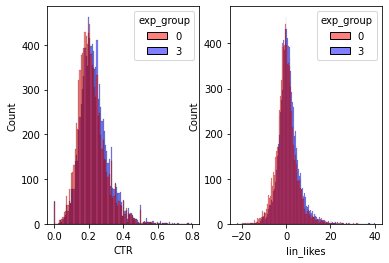

In [10]:
# Распределние CTR и лианеризованных лайков в группах 
plt.subplot(1, 2, 1)
groups = sns.histplot(data = df, 
              x='CTR', 
              hue='exp_group', 
              palette = ['r', 'b'],
              alpha=0.5,
              kde=False)
plt.subplot(1, 2, 2)
groups = sns.histplot(data = df, 
              x='lin_likes', 
              hue='exp_group', 
              palette = ['r', 'b'],
              alpha=0.5,
              kde=False)

# Проанализируем тест между группами 1 и 2 по метрике линеаризованных лайков.

In [11]:
q = """
SELECT exp_group, 
  user_id,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as CTR
FROM simulator_20251220.feed_actions 
WHERE toDate(time) between '2025-11-21' and '2025-11-27'
    and exp_group in (1,2)
GROUP BY exp_group,user_id
"""

In [12]:
df1 = ph.read_clickhouse(q, connection=connection)

In [13]:
df1

,exp_group,user_id,likes,views,CTR
0,1,109963,3,15,0.200000
1,1,26117,32,141,0.226950
2,1,138232,18,73,0.246575
3,1,26295,39,141,0.276596
4,1,18392,7,32,0.218750
...,...,...,...,...,...
19892,2,17146,0,10,0.000000
19893,1,30872,11,59,0.186441
19894,2,25383,42,127,0.330709
19895,2,139020,17,41,0.414634


In [14]:
# Считаем общий CTR в контрольной группе  𝐶𝑇𝑅𝑐𝑜𝑛𝑡𝑟𝑜𝑙=𝑠𝑢𝑚(𝑙𝑖𝑘𝑒𝑠)/𝑠𝑢𝑚(𝑣𝑖𝑒𝑤𝑠)
CTRcontrol1=df1[df1.exp_group==1].likes.sum()/df1[df1.exp_group==1].views.sum()
CTRcontrol1

0.2096041628394293

In [15]:
# Посчитаем в обеих группах поюзерную метрику  𝑙𝑖𝑛𝑒𝑎𝑟𝑖𝑧𝑒𝑑_𝑙𝑖𝑘𝑒𝑠=𝑙𝑖𝑘𝑒𝑠−𝐶𝑇𝑅𝑐𝑜𝑛𝑡𝑟𝑜𝑙∗𝑣𝑖𝑒𝑤𝑠
df1['lin_likes'] = df1['likes'] - CTRcontrol1 * df1['views']
df1

,exp_group,user_id,likes,views,CTR,lin_likes
0,1,109963,3,15,0.200000,-0.144062
1,1,26117,32,141,0.226950,2.445813
2,1,138232,18,73,0.246575,2.698896
3,1,26295,39,141,0.276596,9.445813
4,1,18392,7,32,0.218750,0.292667
...,...,...,...,...,...,...
19892,2,17146,0,10,0.000000,-2.096042
19893,1,30872,11,59,0.186441,-1.366646
19894,2,25383,42,127,0.330709,15.380271
19895,2,139020,17,41,0.414634,8.406229


In [16]:
#сравниваем  t-тестом отличия в группах по метрике 𝑙𝑖𝑛𝑒𝑎𝑟𝑖𝑧𝑒𝑑_𝑙𝑖𝑘𝑒𝑠
stats.ttest_ind(df1[df1.exp_group == 1].lin_likes,
                df1[df1.exp_group == 2].lin_likes,
                equal_var=False)


Ttest_indResult(statistic=5.93637710193448, pvalue=2.9805064038668164e-09)

In [17]:
#сравниваем  t-тестом отличия в группах по метрике CTR
stats.ttest_ind(df1[df1.exp_group == 1].CTR,
                df1[df1.exp_group == 2].CTR,
                equal_var=False)

Ttest_indResult(statistic=0.4051491913112757, pvalue=0.685373331140751)

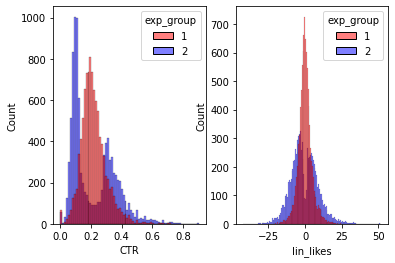

In [18]:
# Распределние CTR и лианеризованных лайков в группах 
plt.subplot(1, 2, 1)
groups = sns.histplot(data = df1, 
              x='CTR', 
              hue='exp_group', 
              palette = ['r', 'b'],
              alpha=0.5,
              kde=False)
plt.subplot(1, 2, 2)
groups = sns.histplot(data = df1, 
              x='lin_likes', 
              hue='exp_group', 
              palette = ['r', 'b'],
              alpha=0.5,
              kde=False)

Согласно результатам t-теста по метрике линеаризованных лайков в группах 1 и 2 p-value очень мал (примерно равен 0, меньше 0.05), это означает, что исследуемая метрика групп отличается в двух группах.

Но согласно результатам t-теста по метрике ctr в группах 1 и 2 p-value очень > 0.05, это означает, что исследуемая метрика групп не отличается в двух группах.

p-value в двух тестах разный, в 1 тесте p-value < 0.05, во 2 тесте по ctr p-value > 0.05
Причина: распределение ctr в группе 2 не похоже на нормальное и двухгорбое.

В t-тесте по метрике линеаризованных лайков p-value меньше.

Без первого теста мы могли сделать неправильный вывод.